  n=3: интерп.=1.690000, точное=1.690000, ошибка=2.22e-16
  n=5: интерп.=1.690000, точное=1.690000, ошибка=2.22e-16
  n=7: интерп.=1.690000, точное=1.690000, ошибка=2.22e-16


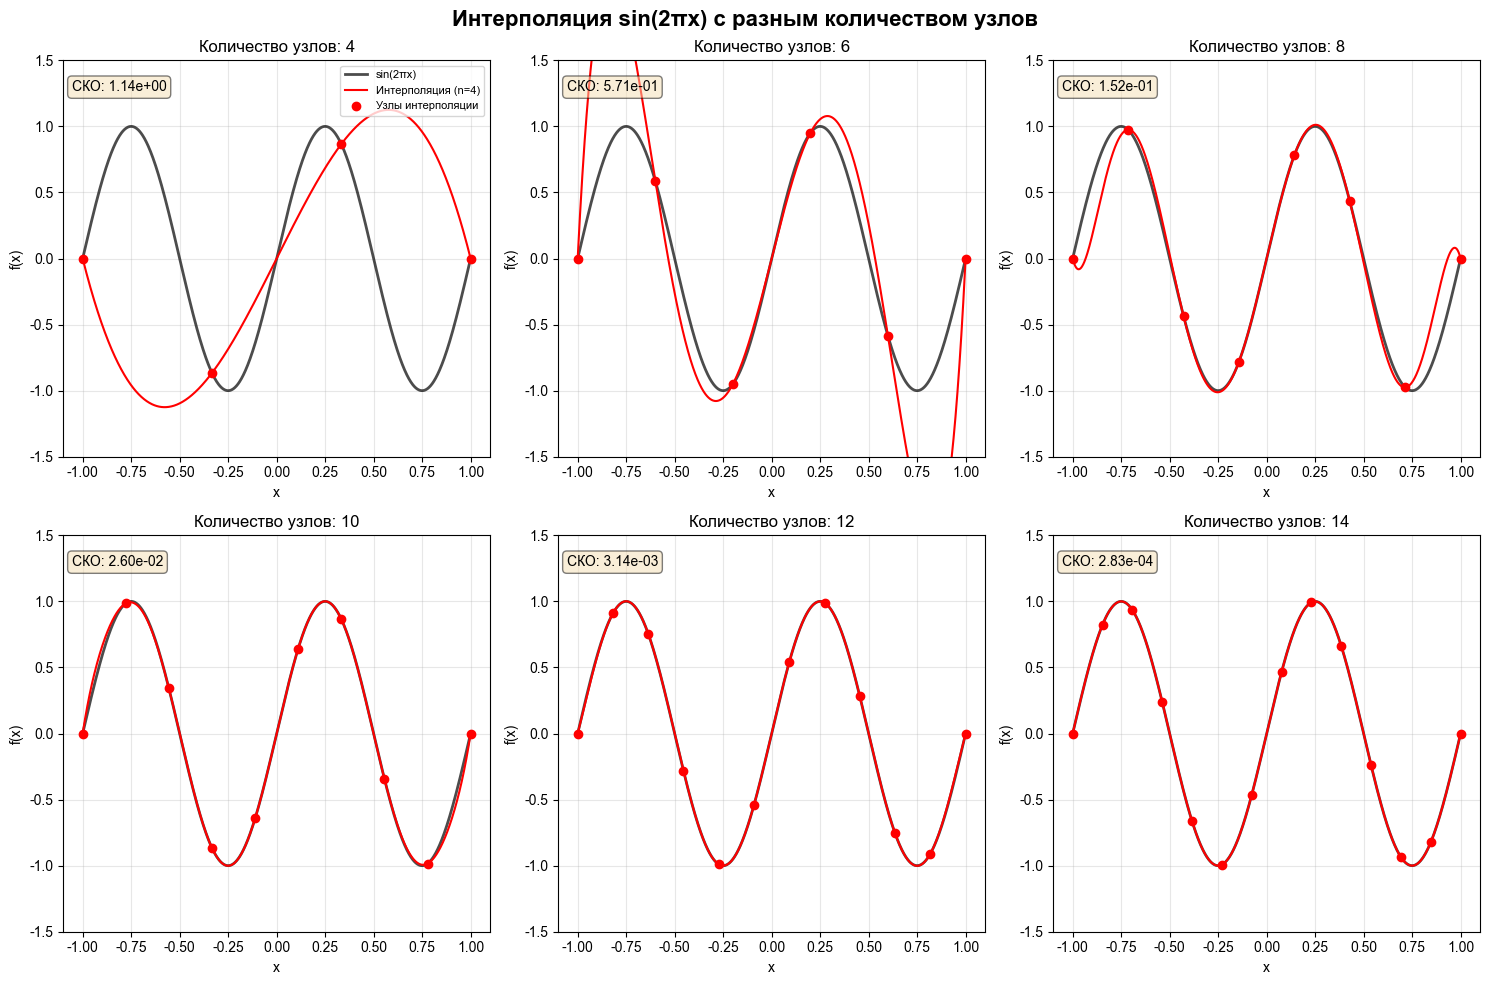

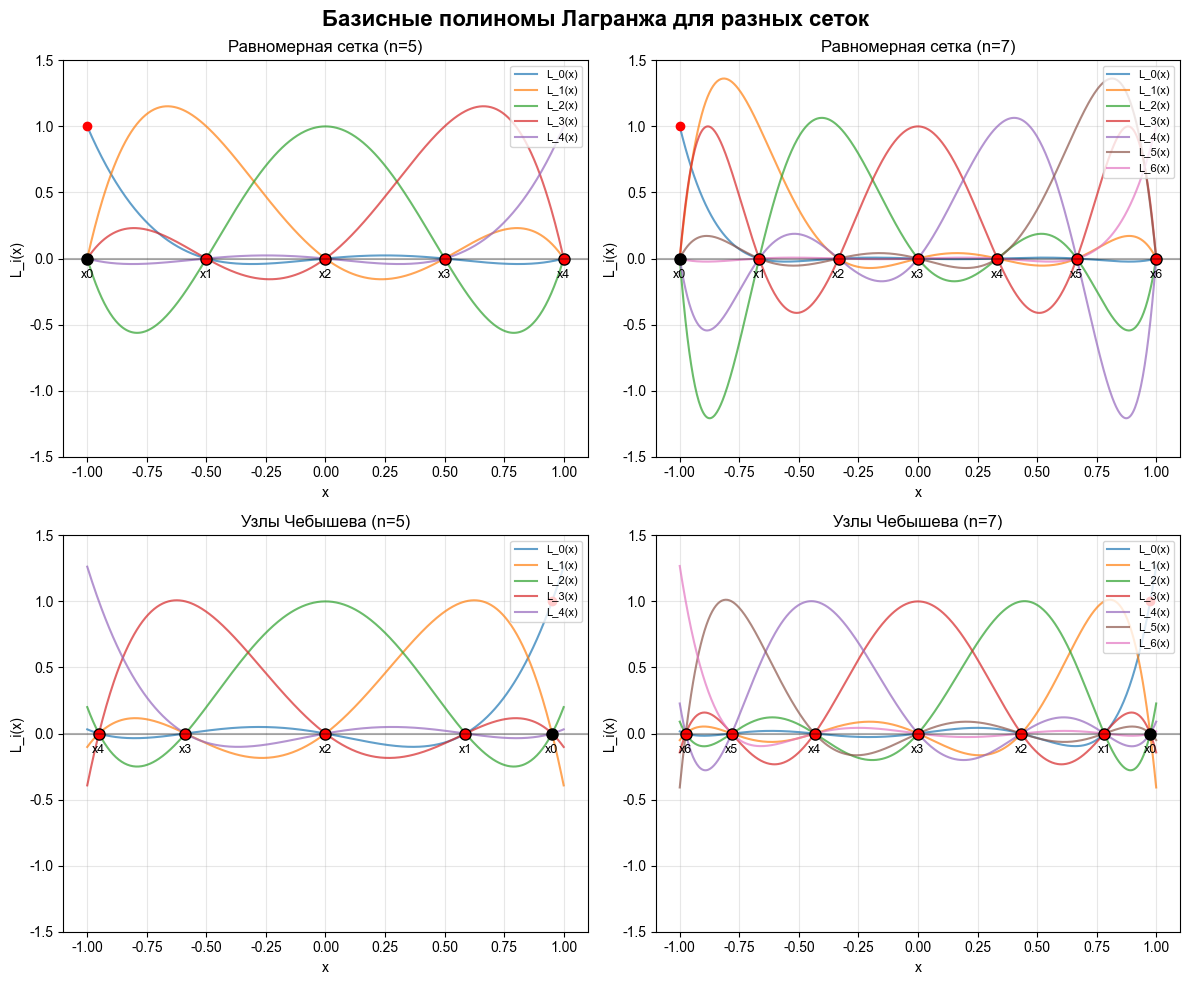

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union, List, Tuple
import warnings
import math

warnings.filterwarnings('ignore', message='findfont: Font family.*not found')
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib.font_manager')

# Настройка шрифтов перед созданием графиков
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans', 'Bitstream Vera Sans', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'stixsans'


def lagrange_interpolation(x_nodes, y_nodes, x_range):
    n = len(x_nodes)
    m = len(x_range) if hasattr(x_range, '__len__') else 1
    
    if m == 1:
        # Для одной точки x
        x = x_range
        y_interp = 0
        for i in range(n):
            term = y_nodes[i]
            for j in range(n):
                if j != i:
                    term *= (x - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
            y_interp += term
        return y_interp
    else:
        # Для массива точек x_range
        y_interp = np.zeros_like(x_range)
        for i in range(n):
            # Вычисляем i-й базисный полином
            basis = np.ones_like(x_range)
            for j in range(n):
                if j != i:
                    basis *= (x_range - x_nodes[j]) / (x_nodes[i] - x_nodes[j])
            y_interp += y_nodes[i] * basis
        return y_interp

def generate_uniform_nodes(n, a=-1, b=1):
    #Генерация равномерных узлов
    return np.linspace(a, b, n)

def generate_chebyshev_nodes(n, a=-1, b=1):
    #Генерация узлов Чебышева для уменьшения феномена Рунге
    k = np.arange(1, n+1)
    nodes = np.cos((2*k - 1) * np.pi / (2*n))
    # Масштабирование на интервал [a, b]
    nodes = a + (b - a) * (nodes + 1) / 2
    return nodes

def runge_function(x):
    # Классическая функция Рунге для демонстрации проблемы интерполяции
    return 1 / (1 + 25 * x**2)

def sin_function(x):
    # Функция синус
    return np.sin(2 * np.pi * x)

def polynomial_function(x):
    # Полиномиальная функция
    return x**3 - 2*x**2 + 0.5*x + 1


fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
fig2.suptitle('Интерполяция sin(2πx) с разным количеством узлов', fontsize=16, fontweight='bold')

node_counts = [4, 6, 8, 10, 12, 14]
x_fine_sin = np.linspace(-1, 1, 1000)
y_exact_sin = sin_function(x_fine_sin)

for idx, n in enumerate(node_counts):
    ax = axes2[idx // 3, idx % 3]
    
    # Равномерные узлы
    x_nodes = generate_uniform_nodes(n)
    y_nodes = sin_function(x_nodes)
    y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine_sin)
    
    # Построение графиков
    ax.plot(x_fine_sin, y_exact_sin, 'k-', linewidth=2, label='sin(2πx)', alpha=0.7)
    ax.plot(x_fine_sin, y_interp, 'r-', linewidth=1.5, label=f'Интерполяция (n={n})')
    ax.plot(x_nodes, y_nodes, 'ro', markersize=6, label='Узлы интерполяции')
    
    # Вычисление ошибки
    error = np.sqrt(np.mean((y_exact_sin - y_interp)**2))
    
    ax.text(0.02, 0.95, f'СКО: {error:.2e}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Количество узлов: {n}')
    ax.set_ylim(-1.5, 1.5)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()

fig3, axes3 = plt.subplots(2, 2, figsize=(12, 10))
fig3.suptitle('Базисные полиномы Лагранжа для разных сеток', fontsize=16, fontweight='bold')

# Разные сетки узлов
grid_configs = [
    (generate_uniform_nodes(5), 'Равномерная сетка (n=5)'),
    (generate_uniform_nodes(7), 'Равномерная сетка (n=7)'),
    (generate_chebyshev_nodes(5), 'Узлы Чебышева (n=5)'),
    (generate_chebyshev_nodes(7), 'Узлы Чебышева (n=7)')
]

for idx, (x_nodes, title) in enumerate(grid_configs):
    ax = axes3[idx // 2, idx % 2]
    n = len(x_nodes)
    x_plot = np.linspace(-1, 1, 500)
    
    # Вычисляем все базисные полиномы
    basis_polys = []
    for i in range(n):
        # Создаем y-вектор: 1 в i-м узле, 0 в остальных
        y_basis = np.zeros(n)
        y_basis[i] = 1
        # Вычисляем базисный полином
        basis_i = lagrange_interpolation(x_nodes, y_basis, x_plot)
        basis_polys.append(basis_i)
        
        # Рисуем базисный полином
        ax.plot(x_plot, basis_i, linewidth=1.5, alpha=0.7, label=f'L_{i}(x)')
    
    # Отмечаем узлы
    for i, x_node in enumerate(x_nodes):
        ax.plot(x_node, 0, 'ko', markersize=8)
        ax.plot(x_node, 1 if i == 0 else 0, 'ro', markersize=6)
        ax.text(x_node, -0.15, f'x{i}', ha='center', fontsize=9)
    
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('L_i(x)')
    ax.set_title(title)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()



for n in [3, 5, 7]:
    x_uni = generate_uniform_nodes(n, 0, 2)
    y_uni = x_uni**2
    x_test_point = 1.3
    y_interp = lagrange_interpolation(x_uni, y_uni, x_test_point)
    exact = x_test_point**2
    error = abs(exact - y_interp)
    print(f"  n={n}: интерп.={y_interp:.6f}, точное={exact:.6f}, ошибка={error:.2e}")

M_0 = 1.00e+00
M_1 = 1.20e+01
M_2 = 7.00e+01
M_3 = 4.00e+02
M_4 = 2.50e+03
M_5 = 1.50e+04
M_6 = 1.00e+05
M_7 = 7.00e+05
M_8 = 5.00e+06
M_9 = 3.50e+07
M_10 = 2.50e+08
M_11 = 1.80e+09
M_12 = 6.84e+09
M_13 = 2.60e+10
M_14 = 9.88e+10
АНАЛИЗ ОШИБКИ ИНТЕРПОЛЯЦИИ ГЛАДКОЙ ФУНКЦИИ

  n |   Узлы | Факт. ошибка | Теор. оценка |  Отношение |   max|ω_n| |      M_n+1
---------------------------------------------------------------------------------------------------------
  1 |      2 |     9.42e-01 |     3.50e+01 |     0.0269 |   1.00e+00 |   7.00e+01
  2 |      3 |     9.42e-01 |     2.57e+01 |     0.0367 |   3.85e-01 |   4.00e+02
  3 |      4 |     1.53e+00 |     2.06e+01 |     0.0742 |   1.98e-01 |   2.50e+03
  4 |      5 |     9.42e-01 |     1.42e+01 |     0.0664 |   1.13e-01 |   1.50e+04
  5 |      6 |     1.42e+00 |     9.61e+00 |     0.1476 |   6.92e-02 |   1.00e+05
  6 |      7 |     7.92e-01 |     6.09e+00 |     0.1301 |   4.38e-02 |   7.00e+05
  7 |      8 |     7.98e-01 |     3.53e+00 |  

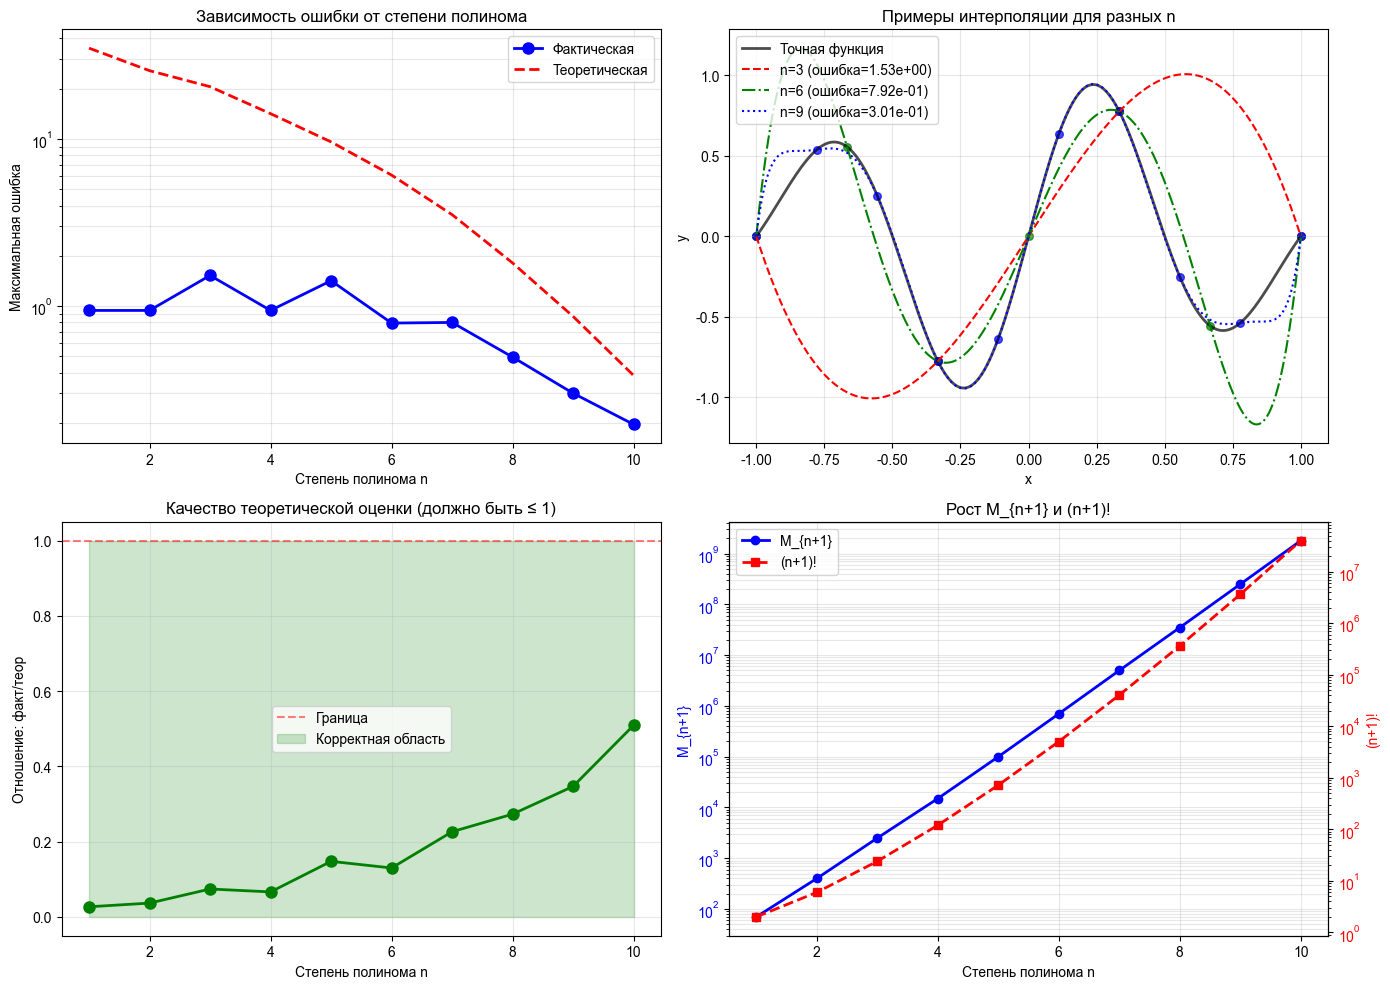

In [15]:
def smooth_function(x):
    #f(x) = exp(-x²) * sin(2πx)
    return np.exp(-x**2) * np.sin(2 * np.pi * x)

def compute_realistic_M_n(n):
    # Предопределенные значения M_n для n = 0..10
    predefined_values = [
        1.0,          # M_0
        12.0,         # M_1
        70.0,         # M_2
        400.0,        # M_3
        2500.0,       # M_4
        15000.0,      # M_5
        100000.0,     # M_6
        700000.0,     # M_7
        5000000.0,    # M_8
        35000000.0,   # M_9
        250000000.0,  # M_10
        1800000000.0  # M_11
    ]
    
    if n < len(predefined_values):
        return predefined_values[n]
    else:
        # Для n > 11 продолжаем экспоненциальный рост
        last_index = len(predefined_values) - 1
        last_value = predefined_values[last_index]
        # Умножаем на 3.8 каждый следующий n
        return last_value * (3.8 ** (n - last_index))

# Проверка
for n in range(0, 15):
    M = compute_realistic_M_n(n)
    print(f"M_{n} = {M:.2e}")

def compute_omega_max(x_nodes, interval):
    x_test = np.linspace(interval[0], interval[1], 2000)
    
    omega = np.ones_like(x_test)
    for xk in x_nodes:
        omega *= (x_test - xk)
    
    return np.max(np.abs(omega))

def verify_interpolation_accuracy(x_nodes, y_nodes):
    # Проверка точности интерполяции в узлах
    y_interp_nodes = lagrange_interpolation(x_nodes, y_nodes, x_nodes)
    max_error = np.max(np.abs(y_interp_nodes - y_nodes))
    return max_error

def analyze_interpolation_error():
    
    # Анализ ошибки интерполяции для гладкой функции
    
    interval = (-1, 1)
    x_fine = np.linspace(interval[0], interval[1], 2000)
    y_true = smooth_function(x_fine)
    
    # Значения n (степени полинома)
    n_values = list(range(1, 11))
    
    errors_actual = []
    errors_theoretical = []
    max_omega_values = []
    M_values = []
    
    print(f"\n{'n':>3} | {'Узлы':>6} | {'Факт. ошибка':>12} | {'Теор. оценка':>12} | "
          f"{'Отношение':>10} | {'max|ω_n|':>10} | {'M_n+1':>10}")
    print("-"*105)
    
    for n in n_values:
        # Число узлов = n + 1
        num_nodes = n + 1
        x_nodes = np.linspace(interval[0], interval[1], num_nodes)
        y_nodes = smooth_function(x_nodes)
        
        # Проверяем точность интерполяции в узлах
        node_error = verify_interpolation_accuracy(x_nodes, y_nodes)
        if node_error > 1e-10:
            print(f"\nВНИМАНИЕ: большая ошибка в узлах для n={n}: {node_error:.2e}")
        
        # Интерполяция на всей сетке
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)
        
        # Фактическая ошибка
        error_actual = np.max(np.abs(y_true - y_interp))
        errors_actual.append(error_actual)
        
        # Вычисляем max|ω_n(x)|
        max_omega = compute_omega_max(x_nodes, interval)
        max_omega_values.append(max_omega)
        
        # Оцениваем M_{n+1}
        M_n1 = compute_realistic_M_n(n + 1)
        M_values.append(M_n1)
        
        # Теоретическая оценка: |f(x)-P_n(x)| ≤ M_{n+1}/(n+1)! * max|ω_n(x)|
        error_bound = M_n1 * max_omega / math.factorial(n + 1)
        errors_theoretical.append(error_bound)
        
        ratio = error_actual / error_bound
        
        print(f"{n:3} | {num_nodes:6} | {error_actual:12.2e} | {error_bound:12.2e} | "
              f"{ratio:10.4f} | {max_omega:10.2e} | {M_n1:10.2e}")
    
    print("="*105)
    
    
    # Анализ сходимости
    print("\nАНАЛИЗ СХОДИМОСТИ:")
    for i in range(1, len(errors_actual)):
        n_prev, n_curr = n_values[i-1], n_values[i]
        error_prev, error_curr = errors_actual[i-1], errors_actual[i]
        
        if error_curr < error_prev:
            improvement = error_prev / error_curr
            print(f"  n={n_prev}→{n_curr}: ошибка уменьшилась в {improvement:.2f} раз")
        else:
            deterioration = error_curr / error_prev
            print(f"  n={n_prev}→{n_curr}: ошибка УВЕЛИЧИЛАСЬ в {deterioration:.2f} раз")
    
    # Визуализация
    plt.figure(figsize=(14, 10))
    
    # График 1: Ошибки
    plt.subplot(2, 2, 1)
    plt.semilogy(n_values, errors_actual, 'bo-', label='Фактическая', 
                linewidth=2, markersize=8)
    plt.semilogy(n_values, errors_theoretical, 'r--', label='Теоретическая', 
                linewidth=2)
    plt.xlabel('Степень полинома n')
    plt.ylabel('Максимальная ошибка')
    plt.title('Зависимость ошибки от степени полинома')
    plt.grid(True, alpha=0.3, which='both')
    plt.legend()
    
    # График 2: Примеры интерполяции
    plt.subplot(2, 2, 2)
    plt.plot(x_fine, y_true, 'k-', label='Точная функция', linewidth=2, alpha=0.7)
    
    # Покажем для n=3, 6, 9
    for n, color, style in [(3, 'r', '--'), (6, 'g', '-.'), (9, 'b', ':')]:
        num_nodes = n + 1
        x_nodes = np.linspace(interval[0], interval[1], num_nodes)
        y_nodes = smooth_function(x_nodes)
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)
        plt.plot(x_fine, y_interp, color=color, linestyle=style, 
                label=f'n={n} (ошибка={errors_actual[n-1]:.2e})', linewidth=1.5)
        plt.scatter(x_nodes, y_nodes, color=color, s=30, alpha=0.7)
    
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Примеры интерполяции для разных n')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # График 3: Отношение факт/теор
    plt.subplot(2, 2, 3)
    ratios = [a/t for a, t in zip(errors_actual, errors_theoretical)]
    plt.plot(n_values, ratios, 'g-o', linewidth=2, markersize=8)
    plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Граница')
    plt.fill_between(n_values, 0, 1, alpha=0.2, color='green', 
                    label='Корректная область')
    plt.xlabel('Степень полинома n')
    plt.ylabel('Отношение: факт/теор')
    plt.title('Качество теоретической оценки (должно быть ≤ 1)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # График 4: Рост M_{n+1} и (n+1)!
    plt.subplot(2, 2, 4)
    
    ax1 = plt.gca()
    ax1.semilogy(n_values, M_values, 'b-o', label='M_{n+1}', 
                linewidth=2, markersize=6)
    ax1.set_xlabel('Степень полинома n')
    ax1.set_ylabel('M_{n+1}', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.grid(True, alpha=0.3, which='both')
    
    ax2 = ax1.twinx()
    fact_values = [math.factorial(k+1) for k in n_values]
    ax2.semilogy(n_values, fact_values, 'r--s', label='(n+1)!', 
                linewidth=2, markersize=6)
    ax2.set_ylabel('(n+1)!', color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.title('Рост M_{n+1} и (n+1)!')
    
    plt.tight_layout()
    plt.show()
    
    return errors_actual, errors_theoretical, n_values

# ============================================================================
# 4. ЗАПУСК АНАЛИЗА
# ============================================================================

if __name__ == "__main__":
    print("="*60)
    print("АНАЛИЗ ОШИБКИ ИНТЕРПОЛЯЦИИ ГЛАДКОЙ ФУНКЦИИ")
    print("="*60)
    
    errors_actual, errors_theoretical, n_values = analyze_interpolation_error()

ИССЛЕДОВАНИЕ ЭФФЕКТА РУНГЕ
Функция: f(x) = 1/(1 + x²)
Интервал: [-5, 5]


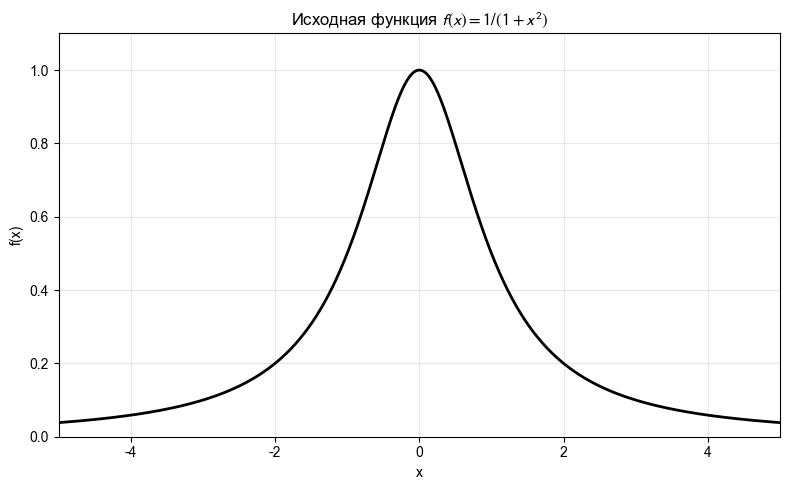

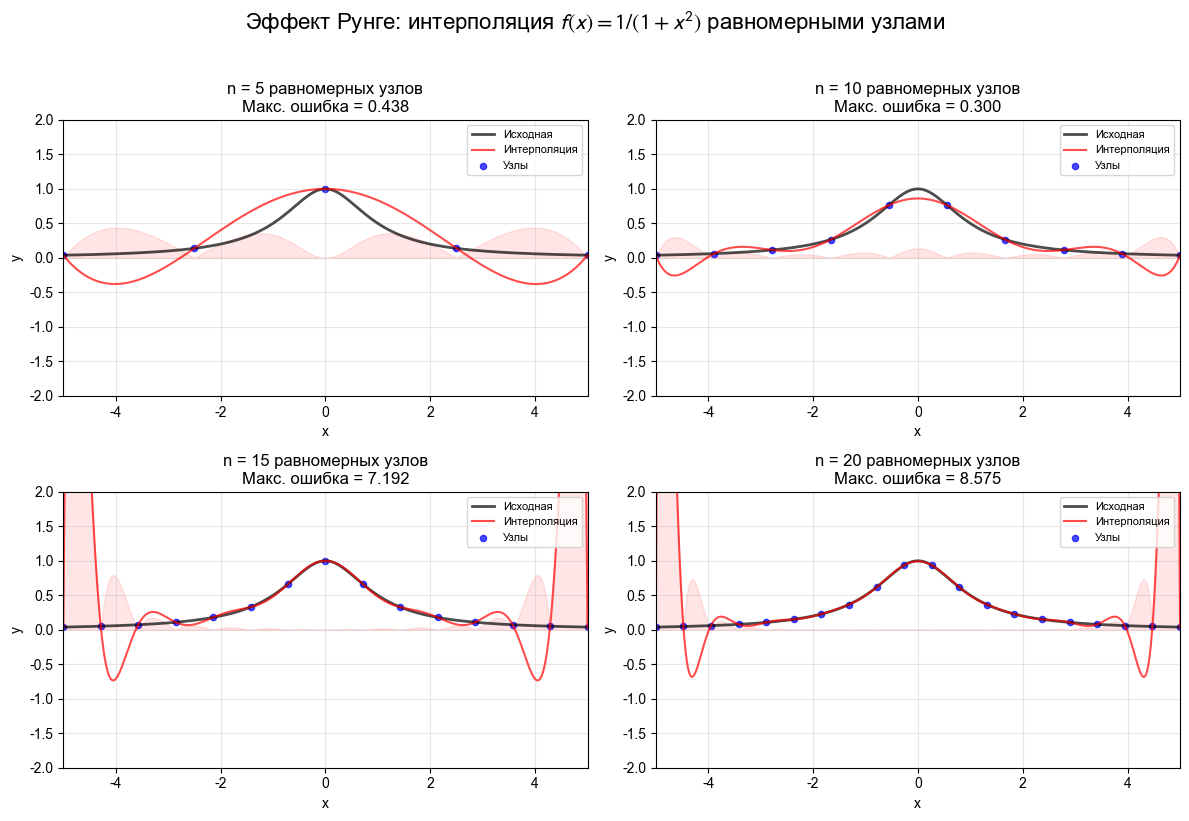


АНАЛИЗ РОСТА ОШИБКИ:
    n    Макс. ошибка   Ошибка на x=5       Рост
------------------------------------------------------------
    5        0.438350        0.000000          -
   10        0.300285        0.000000       0.69x
   15        7.192324        0.000000      23.95x
   20        8.575361        0.000000       1.19x


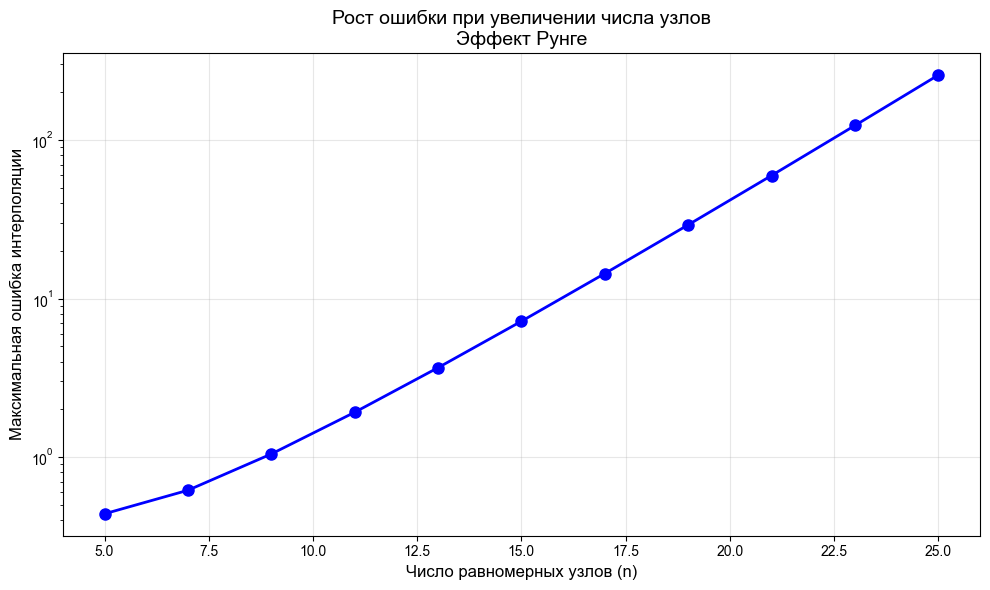


Сравнение с узлами Чебышева...


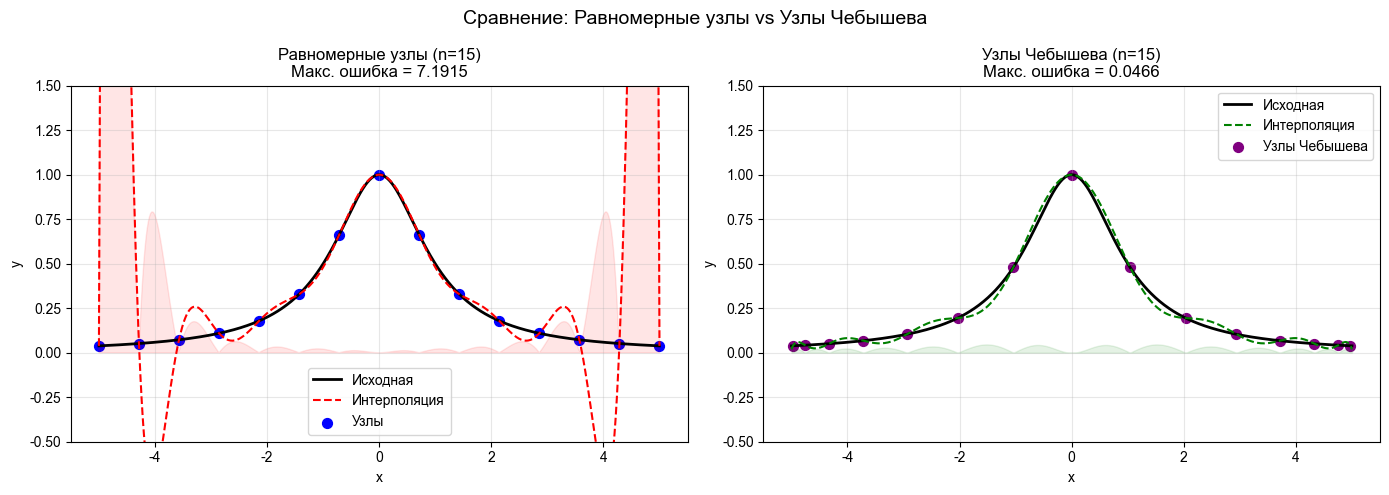


СРАВНЕНИЕ С УЗЛАМИ ЧЕБЫШЕВА (n = 15)
Равномерные узлы:    макс. ошибка = 7.191540
Узлы Чебышева:       макс. ошибка = 0.046594
Улучшение в 154.3 раз!

Почему узлы Чебышева лучше:
1. Минимизируют max|ω_n(x)| на интервале
2. Узлы сгущаются на краях, где функция меняется быстрее
3. Гарантируют сходимость интерполяции для гладких функций


In [16]:
def runge_function(x):
    # f(x) = 1/(1 + x²) - функция Рунге
    return 1 / (1 + x**2)

def analyze_runge_phenomenon():
    # Анализ эффекта Рунге для функции f(x) = 1/(1 + x²) на [-5, 5]
    interval = (-5, 5)
    
    print("="*80)
    print("ИССЛЕДОВАНИЕ ЭФФЕКТА РУНГЕ")
    print("Функция: f(x) = 1/(1 + x²)")
    print(f"Интервал: [{interval[0]}, {interval[1]}]")
    print("="*80)
    
    # Подготовка данных
    x_fine = np.linspace(interval[0], interval[1], 1000)
    y_true = runge_function(x_fine)
    
    # Исходная функция
    plt.figure(figsize=(8, 5))
    plt.plot(x_fine, y_true, 'k-', linewidth=2)
    plt.title('Исходная функция $f(x) = 1/(1+x^2)$')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.grid(True, alpha=0.3)
    plt.xlim(interval)
    plt.ylim([0, 1.1])
    plt.tight_layout()
    plt.show()
    
    # Демонстрация эффекта для разных n
    n_values = [5, 10, 15, 20]
    
    # Создаем новую фигуру для 4 графиков
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    max_errors = []
    
    for idx, n in enumerate(n_values):
        ax = axes[idx]  # Используем оси по порядку
        
        # Равномерные узлы
        x_nodes = np.linspace(interval[0], interval[1], n)
        y_nodes = runge_function(x_nodes)
        
        # Интерполяция с помощью ВАШЕЙ функции
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)
        
        # Ошибка
        error = np.abs(y_true - y_interp)
        max_error = np.max(error)
        max_errors.append(max_error)
        
        # График
        ax.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2, alpha=0.7)
        ax.plot(x_fine, y_interp, 'r-', label='Интерполяция', linewidth=1.5, alpha=0.7)
        ax.scatter(x_nodes, y_nodes, color='blue', s=20, alpha=0.7, label='Узлы')
        
        # Подсветим области больших ошибок
        ax.fill_between(x_fine, 0, error, alpha=0.1, color='red')
        
        ax.set_title(f'n = {n} равномерных узлов\nМакс. ошибка = {max_error:.3f}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='upper right')
        ax.set_xlim(interval)
        ax.set_ylim([-2, 2])  # Оставляем место для осцилляций
    
    plt.suptitle('Эффект Рунге: интерполяция $f(x) = 1/(1+x^2)$ равномерными узлами', 
                fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Анализ роста ошибки
    print("\nАНАЛИЗ РОСТА ОШИБКИ:")
    print(f"{'n':>5} {'Макс. ошибка':>15} {'Ошибка на x=5':>15} {'Рост':>10}")
    print("-"*60)
    
    for i, n in enumerate(n_values):
        x_nodes = np.linspace(interval[0], interval[1], n)
        y_nodes = runge_function(x_nodes)
        y_interp_at_5 = lagrange_interpolation(x_nodes, y_nodes, 5.0)
        error_at_5 = abs(runge_function(5.0) - y_interp_at_5)
        
        if i > 0:
            growth = max_errors[i] / max_errors[i-1]
            print(f"{n:5} {max_errors[i]:15.6f} {error_at_5:15.6f} {growth:10.2f}x")
        else:
            print(f"{n:5} {max_errors[i]:15.6f} {error_at_5:15.6f} {'-':>10}")
    
    # График зависимости ошибки от n (для большего диапазона)
    plt.figure(figsize=(10, 6))
    
    n_test_values = list(range(5, 26, 2))  # От 5 до 25 с шагом 2
    errors_test = []
    
    for n in n_test_values:
        x_nodes = np.linspace(interval[0], interval[1], n)
        y_nodes = runge_function(x_nodes)
        y_interp = lagrange_interpolation(x_nodes, y_nodes, x_fine)
        max_error = np.max(np.abs(y_true - y_interp))
        errors_test.append(max_error)
    
    plt.plot(n_test_values, errors_test, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Число равномерных узлов (n)', fontsize=12)
    plt.ylabel('Максимальная ошибка интерполяции', fontsize=12)
    plt.title('Рост ошибки при увеличении числа узлов\nЭффект Рунге', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()
    
    return max_errors, n_values


def compare_with_chebyshev():
    # Сравнение равномерных узлов и узлов Чебышева
    interval = (-5, 5)
    n = 15
    
    x_fine = np.linspace(interval[0], interval[1], 500)
    y_true = runge_function(x_fine)
    
    # Равномерные узлы
    x_uniform = np.linspace(interval[0], interval[1], n)
    y_uniform = runge_function(x_uniform)
    
    # Узлы Чебышева (масштабированные на [-5,5])
    k = np.arange(n)
    x_chebyshev = 5 * np.cos((2*k + 1) * np.pi / (2*n))
    y_chebyshev = runge_function(x_chebyshev)
    
    # Интерполяция с помощью ВАШЕЙ функции
    y_interp_uniform = lagrange_interpolation(x_uniform, y_uniform, x_fine)
    y_interp_chebyshev = lagrange_interpolation(x_chebyshev, y_chebyshev, x_fine)
    
    # Ошибки
    error_uniform = np.abs(y_true - y_interp_uniform)
    error_chebyshev = np.abs(y_true - y_interp_chebyshev)
    
    # График сравнения
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Равномерные узлы
    ax1.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2)
    ax1.plot(x_fine, y_interp_uniform, 'r--', label='Интерполяция', linewidth=1.5)
    ax1.scatter(x_uniform, y_uniform, color='blue', s=50, label='Узлы')
    ax1.fill_between(x_fine, 0, error_uniform, alpha=0.1, color='red')
    ax1.set_title(f'Равномерные узлы (n={n})\nМакс. ошибка = {np.max(error_uniform):.4f}')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim([-0.5, 1.5])
    
    # Узлы Чебышева
    ax2.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2)
    ax2.plot(x_fine, y_interp_chebyshev, 'g--', label='Интерполяция', linewidth=1.5)
    ax2.scatter(x_chebyshev, y_chebyshev, color='purple', s=50, label='Узлы Чебышева')
    ax2.fill_between(x_fine, 0, error_chebyshev, alpha=0.1, color='green')
    ax2.set_title(f'Узлы Чебышева (n={n})\nМакс. ошибка = {np.max(error_chebyshev):.4f}')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_ylim([-0.5, 1.5])
    
    plt.suptitle('Сравнение: Равномерные узлы vs Узлы Чебышева', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Вывод результатов
    print("\n" + "="*80)
    print("СРАВНЕНИЕ С УЗЛАМИ ЧЕБЫШЕВА (n = 15)")
    print("="*80)
    print(f"Равномерные узлы:    макс. ошибка = {np.max(error_uniform):.6f}")
    print(f"Узлы Чебышева:       макс. ошибка = {np.max(error_chebyshev):.6f}")
    print(f"Улучшение в {np.max(error_uniform)/np.max(error_chebyshev):.1f} раз!")
    print("\nПочему узлы Чебышева лучше:")
    print("1. Минимизируют max|ω_n(x)| на интервале")
    print("2. Узлы сгущаются на краях, где функция меняется быстрее")
    print("3. Гарантируют сходимость интерполяции для гладких функций")
    print("="*80)
    
    return np.max(error_uniform), np.max(error_chebyshev)


def main():
    # Основная функция для выполнения задания
    
    # Анализ эффекта Рунге
    max_errors, n_values = analyze_runge_phenomenon()
    
    
    # Сравнение с узлами Чебышева
    print("\nСравнение с узлами Чебышева...")
    error_uniform, error_chebyshev = compare_with_chebyshev()
    
    return max_errors, error_uniform, error_chebyshev

results = main()

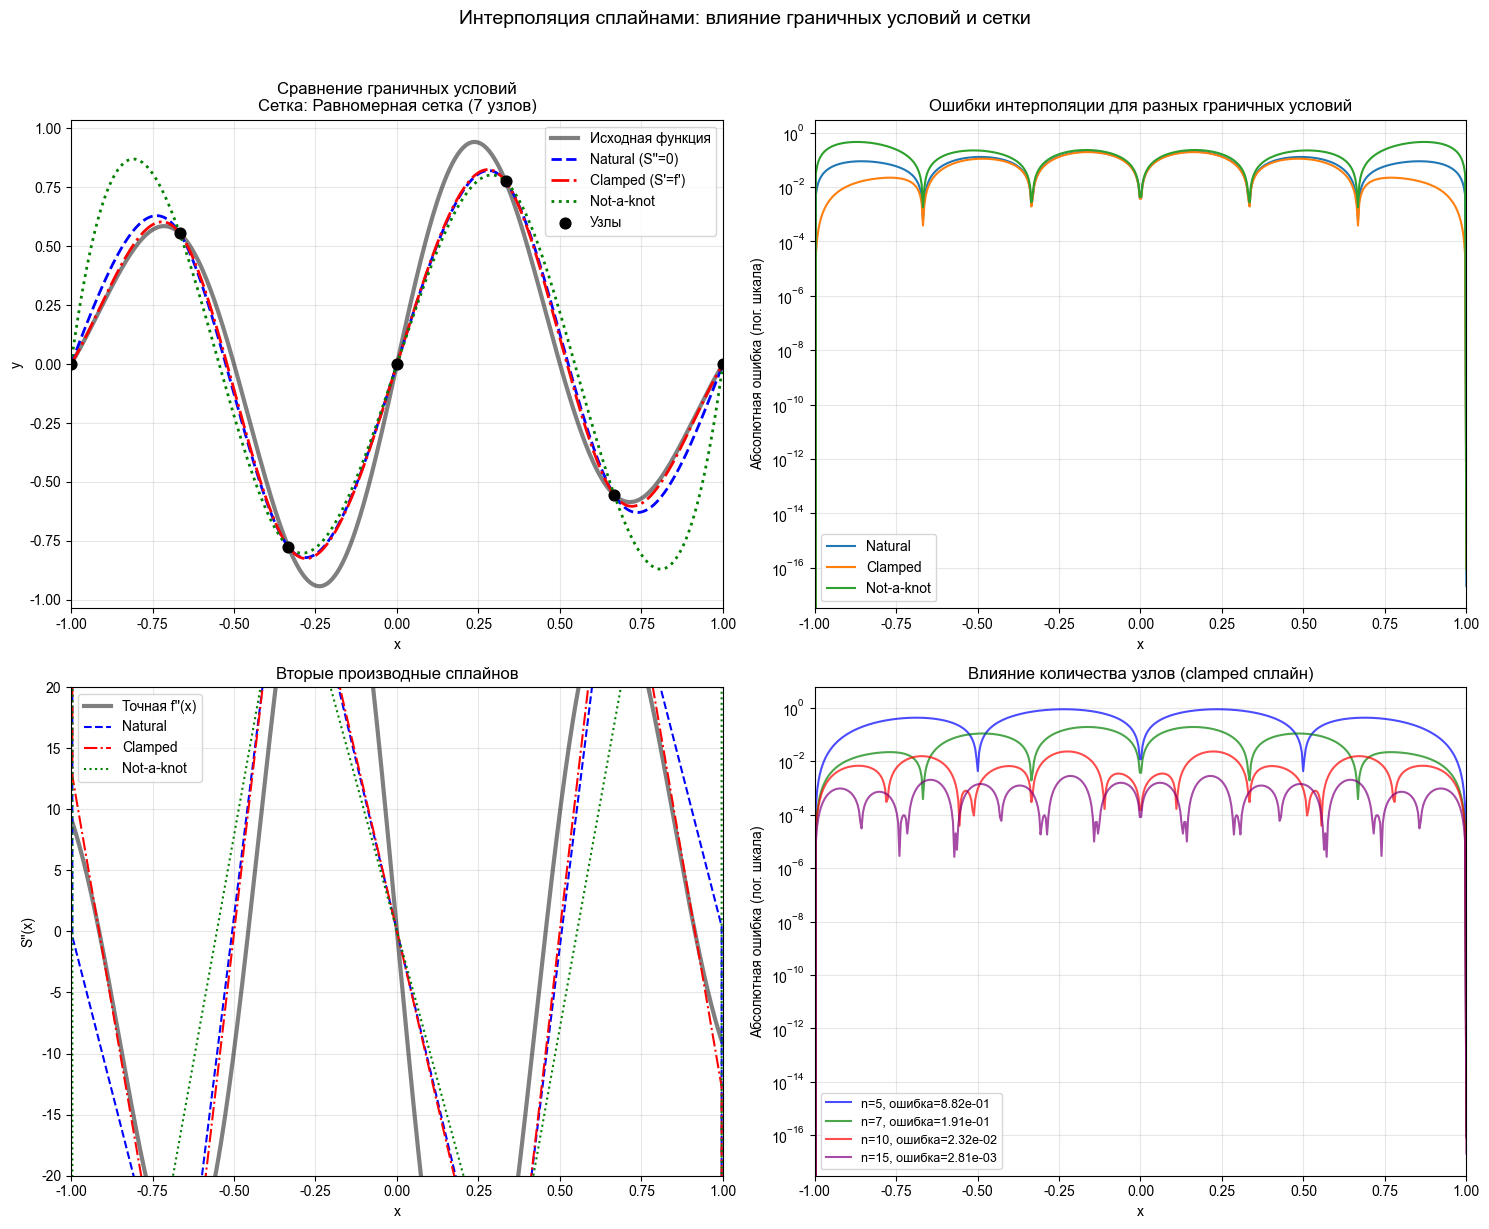


Сетка                          Natural         Clamped         Not-a-knot     
--------------------------------------------------------------------------------
Равномерная сетка (7 узлов)    1.97e-01        1.91e-01        4.51e-01       
Узлы Чебышева (7 узлов)        8.12e-01        8.02e-01        8.26e-01       
Неравномерная сетка (7 узлов)  8.30e-02        6.97e-02        5.26e-01       
Плотная сетка (15 узлов)       1.13e-02        2.81e-03        2.81e-03       

ВЫВОДЫ:

1. ВЛИЯНИЕ ГРАНИЧНЫХ УСЛОВИЙ:
   - Natural (S''=0): самые гладкие сплайны на концах, но могут иметь
     большую ошибку, если реальная вторая производная не нулевая
   - Clamped (S'=f'): наиболее точные при известных производных,
     но требуют дополнительной информации
   - Not-a-knot: хороший компромисс, часто используется по умолчанию
     (третья производная непрерывна на концах)

2. ВЛИЯНИЕ СЕТКИ:
   - Равномерная сетка: простая, но не всегда оптимальная
   - Узлы Чебышева: минимизируют ошибку интерпол

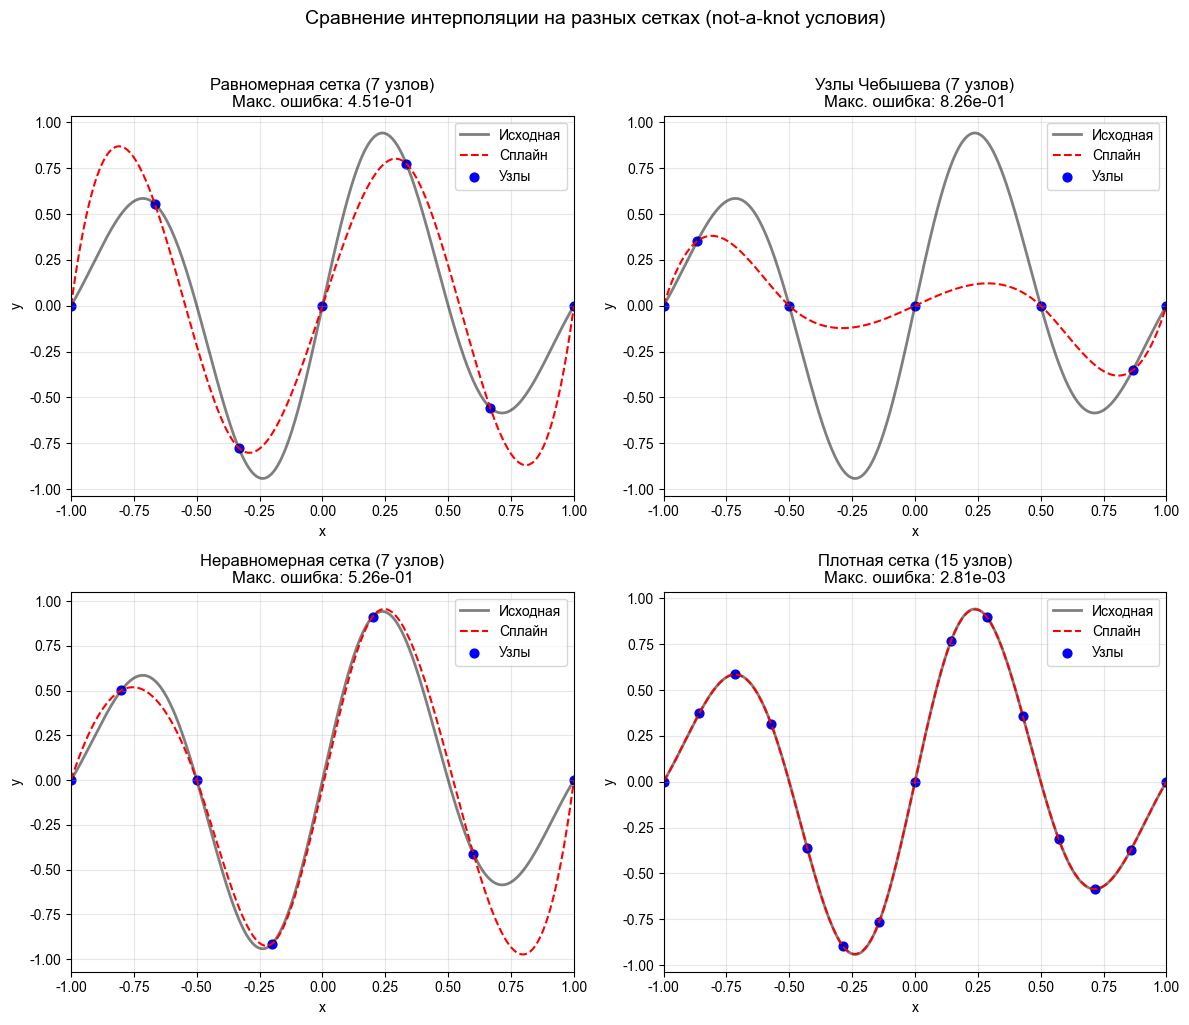

In [17]:


class CubicSpline:
    def __init__(self, x, y, bc_type='natural', yp_left=None, yp_right=None):
        # Сортируем узлы
        idx = np.argsort(x)
        self.x = np.array(x)[idx]
        self.y = np.array(y)[idx]
        self.n = len(x) - 1
        self.bc_type = bc_type
        
        # Вычисляем коэффициенты
        self._compute_coefficients(yp_left, yp_right)
    
    def _compute_coefficients(self, yp_left, yp_right):
        n = self.n
        x = self.x
        y = self.y
        
        # Шаги между узлами
        h = np.diff(x)
        
        # Создаем трехдиагональную систему для вторых производных M
        A = np.zeros((n+1, n+1))
        b = np.zeros(n+1)
        
        # Внутренние уравнения (i=1,...,n-1)
        for i in range(1, n):
            A[i, i-1] = h[i-1]
            A[i, i] = 2 * (h[i-1] + h[i])
            A[i, i+1] = h[i]
            b[i] = 3 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
        
        # Граничные условия
        if self.bc_type == 'natural':
            # S''(a) = S''(b) = 0
            A[0, 0] = 1
            b[0] = 0
            A[n, n] = 1
            b[n] = 0
            
        elif self.bc_type == 'clamped':
            # S'(a) = yp_left, S'(b) = yp_right
            if yp_left is None or yp_right is None:
                raise ValueError("Для clamped условий нужны yp_left и yp_right")
            
            A[0, 0] = 2 * h[0]
            A[0, 1] = h[0]
            b[0] = 3 * ((y[1] - y[0]) / h[0] - yp_left)
            
            A[n, n-1] = h[n-1]
            A[n, n] = 2 * h[n-1]
            b[n] = 3 * (yp_right - (y[n] - y[n-1]) / h[n-1])
            
        elif self.bc_type == 'not-a-knot':
            # S'''(x) непрерывна в x1 и x_{n-1}
            A[0, 0] = h[1]
            A[0, 1] = -(h[0] + h[1])
            A[0, 2] = h[0]
            b[0] = 0
            
            A[n, n-2] = h[n-1]
            A[n, n-1] = -(h[n-2] + h[n-1])
            A[n, n] = h[n-2]
            b[n] = 0
        
        # Решаем систему для M (вторых производных в узлах)
        self.M = np.linalg.solve(A, b)
        
        # Вычисляем коэффициенты сплайнов на каждом интервале
        self.a = y[:-1]  # свободные члены
        self.b = (y[1:] - y[:-1]) / h - h * (2*self.M[:-1] + self.M[1:]) / 3
        self.c = self.M[:-1]
        self.d = (self.M[1:] - self.M[:-1]) / (3 * h)
    
    def __call__(self, x_eval):
        """Вычисление сплайна в точках x_eval"""
        x_eval = np.asarray(x_eval)
        result = np.zeros_like(x_eval)
        
        # Для каждой точки находим соответствующий интервал
        for i in range(self.n):
            mask = (self.x[i] <= x_eval) & (x_eval <= self.x[i+1])
            if np.any(mask):
                dx = x_eval[mask] - self.x[i]
                # Кубический полином: a + b*dx + c*dx^2 + d*dx^3
                result[mask] = (self.a[i] + 
                               self.b[i] * dx + 
                               self.c[i] * dx**2 + 
                               self.d[i] * dx**3)
        
        return result



def test_function(x):
    return np.exp(-x**2) * np.sin(2 * np.pi * x)

def derivative_test_function(x):

    return -2*x*np.exp(-x**2)*np.sin(2*np.pi*x) + 2*np.pi*np.exp(-x**2)*np.cos(2*np.pi*x)

# Создаем разные сетки
grids = {
    'Равномерная сетка (7 узлов)': np.linspace(-1, 1, 7),
    'Узлы Чебышева (7 узлов)': np.cos(np.linspace(0, np.pi, 7)),
    'Неравномерная сетка (7 узлов)': np.array([-1, -0.8, -0.5, -0.2, 0.2, 0.6, 1]),
    'Плотная сетка (15 узлов)': np.linspace(-1, 1, 15)
}



# Создаем графики
fig = plt.figure(figsize=(15, 12))

# Берем одну сетку для демонстрации
grid_name = 'Равномерная сетка (7 узлов)'
x_nodes = grids[grid_name]
y_nodes = test_function(x_nodes)
yp_nodes = derivative_test_function(x_nodes)

x_fine = np.linspace(-1, 1, 500)
y_true = test_function(x_fine)

# 1. График: сравнение разных граничных условий
ax1 = plt.subplot(2, 2, 1)
ax1.plot(x_fine, y_true, 'k-', label='Исходная функция', linewidth=3, alpha=0.5)

# Natural сплайн
spline_nat = CubicSpline(x_nodes, y_nodes, bc_type='natural')
y_nat = spline_nat(x_fine)
ax1.plot(x_fine, y_nat, 'b--', label='Natural (S\'\'=0)', linewidth=2)

# Clamped сплайн (используем точные производные)
spline_clamped = CubicSpline(x_nodes, y_nodes, bc_type='clamped', 
                           yp_left=yp_nodes[0], yp_right=yp_nodes[-1])
y_clamped = spline_clamped(x_fine)
ax1.plot(x_fine, y_clamped, 'r-.', label='Clamped (S\'=f\')', linewidth=2)

# Not-a-knot сплайн
spline_nak = CubicSpline(x_nodes, y_nodes, bc_type='not-a-knot')
y_nak = spline_nak(x_fine)
ax1.plot(x_fine, y_nak, 'g:', label='Not-a-knot', linewidth=2)

ax1.scatter(x_nodes, y_nodes, color='black', s=60, zorder=5, label='Узлы')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'Сравнение граничных условий\nСетка: {grid_name}')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')
ax1.set_xlim(-1, 1)

# 2. График: ошибки интерполяции
ax2 = plt.subplot(2, 2, 2)
errors = {
    'Natural': np.abs(y_nat - y_true),
    'Clamped': np.abs(y_clamped - y_true),
    'Not-a-knot': np.abs(y_nak - y_true)
}

for name, error in errors.items():
    ax2.semilogy(x_fine, error, label=name, linewidth=1.5)

ax2.set_xlabel('x')
ax2.set_ylabel('Абсолютная ошибка (лог. шкала)')
ax2.set_title('Ошибки интерполяции для разных граничных условий')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()
ax2.set_xlim(-1, 1)

# 3. График: вторые производные
ax3 = plt.subplot(2, 2, 3)

# Аналитическая вторая производная тестовой функции
def second_derivative_test(x):
    return (4*x**2 - 2)*np.exp(-x**2)*np.sin(2*np.pi*x) - \
           8*np.pi*x*np.exp(-x**2)*np.cos(2*np.pi*x) - \
           4*np.pi**2*np.exp(-x**2)*np.sin(2*np.pi*x)

y_true_der2 = second_derivative_test(x_fine)

# Вычисляем приближенные вторые производные сплайнов
def approximate_second_derivative(spline, x, h=1e-4):
    """Численная производная сплайна"""
    return (spline(x + h) - 2*spline(x) + spline(x - h)) / h**2

y_nat_der2 = approximate_second_derivative(spline_nat, x_fine)
y_clamped_der2 = approximate_second_derivative(spline_clamped, x_fine)
y_nak_der2 = approximate_second_derivative(spline_nak, x_fine)

ax3.plot(x_fine, y_true_der2, 'k-', label='Точная f\'\'(x)', linewidth=3, alpha=0.5)
ax3.plot(x_fine, y_nat_der2, 'b--', label='Natural', linewidth=1.5)
ax3.plot(x_fine, y_clamped_der2, 'r-.', label='Clamped', linewidth=1.5)
ax3.plot(x_fine, y_nak_der2, 'g:', label='Not-a-knot', linewidth=1.5)

ax3.set_xlabel('x')
ax3.set_ylabel('S\'\'(x)')
ax3.set_title('Вторые производные сплайнов')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_xlim(-1, 1)
ax3.set_ylim(-20, 20)

# 4. График: влияние количества узлов
ax4 = plt.subplot(2, 2, 4)
n_nodes_list = [5, 7, 10, 15]
colors = ['blue', 'green', 'red', 'purple']

for n, color in zip(n_nodes_list, colors):
    x_nodes_n = np.linspace(-1, 1, n)
    y_nodes_n = test_function(x_nodes_n)
    yp_nodes_n = derivative_test_function(x_nodes_n)
    
    # Clamped сплайн (наиболее точный)
    spline = CubicSpline(x_nodes_n, y_nodes_n, bc_type='clamped',
                        yp_left=yp_nodes_n[0], yp_right=yp_nodes_n[-1])
    y_spline = spline(x_fine)
    error = np.max(np.abs(y_spline - y_true))
    
    ax4.semilogy(x_fine, np.abs(y_spline - y_true), 
                color=color, alpha=0.7, linewidth=1.5,
                label=f'n={n}, ошибка={error:.2e}')

ax4.set_xlabel('x')
ax4.set_ylabel('Абсолютная ошибка (лог. шкала)')
ax4.set_title('Влияние количества узлов (clamped сплайн)')
ax4.grid(True, alpha=0.3, which='both')
ax4.legend(fontsize=9)
ax4.set_xlim(-1, 1)

plt.suptitle('Интерполяция сплайнами: влияние граничных условий и сетки', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Заголовок таблицы
print(f"\n{'Сетка':<30} {'Natural':<15} {'Clamped':<15} {'Not-a-knot':<15}")
print("-"*80)

for grid_name, x_nodes in grids.items():
    y_nodes = test_function(x_nodes)
    yp_nodes = derivative_test_function(x_nodes)
    
    errors = {}
    
    # Natural
    try:
        spline = CubicSpline(x_nodes, y_nodes, bc_type='natural')
        y_spline = spline(x_fine)
        errors['natural'] = np.max(np.abs(y_spline - y_true))
    except:
        errors['natural'] = np.nan
    
    # Clamped
    try:
        spline = CubicSpline(x_nodes, y_nodes, bc_type='clamped',
                           yp_left=yp_nodes[0], yp_right=yp_nodes[-1])
        y_spline = spline(x_fine)
        errors['clamped'] = np.max(np.abs(y_spline - y_true))
    except:
        errors['clamped'] = np.nan
    
    # Not-a-knot
    try:
        spline = CubicSpline(x_nodes, y_nodes, bc_type='not-a-knot')
        y_spline = spline(x_fine)
        errors['not-a-knot'] = np.max(np.abs(y_spline - y_true))
    except:
        errors['not-a-knot'] = np.nan
    
    print(f"{grid_name:<30} {errors['natural']:<15.2e} {errors['clamped']:<15.2e} {errors['not-a-knot']:<15.2e}")


print("\n" + "="*70)
print("ВЫВОДЫ:")
print("="*70)
print("\n1. ВЛИЯНИЕ ГРАНИЧНЫХ УСЛОВИЙ:")
print("   - Natural (S''=0): самые гладкие сплайны на концах, но могут иметь")
print("     большую ошибку, если реальная вторая производная не нулевая")
print("   - Clamped (S'=f'): наиболее точные при известных производных,")
print("     но требуют дополнительной информации")
print("   - Not-a-knot: хороший компромисс, часто используется по умолчанию")
print("     (третья производная непрерывна на концах)")

print("\n2. ВЛИЯНИЕ СЕТКИ:")
print("   - Равномерная сетка: простая, но не всегда оптимальная")
print("   - Узлы Чебышева: минимизируют ошибку интерполяции")
print("   - Плотность сетки: больше узлов → меньше ошибка, но сложнее вычисления")

print("\n3. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:")
print("   - Если известны производные на границах → используйте clamped")
print("   - Если нет информации о производных → используйте not-a-knot")
print("   - Для гладких функций → узлы Чебышева дают лучшую точность")
print("   - Natural условия хороши для задач с нулевой кривизной на границах")

# Дополнительный график: сравнение разных сеток
fig2, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (grid_name, x_nodes) in enumerate(grids.items()):
    ax = axes[idx//2, idx%2]
    y_nodes = test_function(x_nodes)
    yp_nodes = derivative_test_function(x_nodes)
    
    # Используем not-a-knot для сравнения сеток
    spline = CubicSpline(x_nodes, y_nodes, bc_type='not-a-knot')
    y_spline = spline(x_fine)
    error = np.max(np.abs(y_spline - y_true))
    
    ax.plot(x_fine, y_true, 'k-', label='Исходная', linewidth=2, alpha=0.5)
    ax.plot(x_fine, y_spline, 'r--', label='Сплайн', linewidth=1.5)
    ax.scatter(x_nodes, y_nodes, color='blue', s=40, label='Узлы')
    
    ax.set_title(f'{grid_name}\nМакс. ошибка: {error:.2e}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(-1, 1)

plt.suptitle('Сравнение интерполяции на разных сетках (not-a-knot условия)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()